<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2d6a9f 100%); padding: 40px 32px 32px 32px; border-radius: 12px; margin-bottom: 8px;">
  <h1 style="color: #ffffff; font-size: 2.0em; margin: 0 0 6px 0; font-family: 'Segoe UI', sans-serif; font-weight: 700;">
    Week 10, Lesson 17 (Data Science Track) -- Convolutional Neural Networks
  </h1>
  <h2 style="color: #a8d4f5; font-size: 1.2em; margin: 0 0 18px 0; font-family: 'Segoe UI', sans-serif; font-weight: 400;">
    Kernels, Feature Maps, and Your First Image Classifier -- on Fashion-MNIST
  </h2>
  <hr style="border: 1px solid rgba(255,255,255,0.25); margin: 16px 0;">
  <table style="color: #cce4ff; font-family: 'Segoe UI', sans-serif; font-size: 0.95em;">
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Week:</strong></td><td>10 of 16 -- Convolutional Neural Networks</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Duration:</strong></td><td>40 minutes</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Phase:</strong></td><td>Month 3 -- Deep Learning</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Track:</strong></td><td>Data Science</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Instructor:</strong></td><td>Dr. Daniel Wamriew</td>
      <td style="padding: 3px 24px 3px 32px;"><strong>Contact:</strong></td><td>wamriewdan@gmail.com</td>
    </tr>
  </table>
</div>

<div style="background: #e8f5e9; border-left: 5px solid #2ca87f; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### How to Use This Notebook

Work through this notebook **from top to bottom**, pressing **Shift + Enter** on each cell to run it.

- **Code cells** contain Python -- run them and read the output carefully.
- **Markdown cells** (white background) contain explanations -- read before running the next cell.
- **Student Activity** cells are marked `Activity` -- complete these before the homework.

This is the **Data Science track** version of Lesson 17. It covers the exact same concepts as the
Petroleum Engineering track notebook (convolution, kernels, pooling, your first CNN) but classifies
real images from a well-known public dataset -- **Fashion-MNIST** -- instead of seismic patches.
Everything downloads automatically the first time you run Section 6; after that it's cached locally.
</div>

---
## Table of Contents

1. [From Tabular Data to Images: Why Flatten-and-Dense Doesn't Scale](#1-from-tabular-data-to-images-why-flatten-and-dense-doesnt-scale)
2. [The Convolution Operation, By Hand](#2-the-convolution-operation-by-hand)
3. [Kernels as Pattern Detectors](#3-kernels-as-pattern-detectors)
4. [Pooling: Keeping What Matters](#4-pooling-keeping-what-matters)
5. [Building Blocks in PyTorch: Conv2d, MaxPool2d, Flatten](#5-building-blocks-in-pytorch-conv2d-maxpool2d-flatten)
6. [A Real Public Dataset: Fashion-MNIST](#6-a-real-public-dataset-fashion-mnist)
7. [Your First CNN with nn.Sequential](#7-your-first-cnn-with-nnsequential)
8. [Loss and Optimizer for Image Classification](#8-loss-and-optimizer-for-image-classification)
9. [The Training Loop](#9-the-training-loop)
10. [Evaluate: Accuracy on Held-Out Images](#10-evaluate-accuracy-on-held-out-images)
11. [Student Activity](#11-student-activity)
12. [Recap & Homework](#12-recap--homework)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print("Device:", torch.device("cpu"))

PyTorch version: 2.13.0+cu130
Device: cpu


---
## 1. From Tabular Data to Images: Why Flatten-and-Dense Doesn't Scale

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Every network so far (Lessons 15-16) took a **row of numbers** as input -- a handful of scaled
features, order doesn't matter, each one independent of its neighbours.

An image is different. A 28x28 grayscale image has 784 pixels, and **where** a pixel sits relative to
its neighbours is the entire point -- a shoe's silhouette is a spatial *pattern*, not a list of
independent brightness values.

Two problems if we just flatten the image and feed it to `nn.Linear`, like we did in Lesson 16:

1. **Parameter explosion.** A first hidden layer of only 16 neurons over 784 flattened pixels is
   already `784 x 16 = 12,544` weights -- for one tiny layer, on one small image.
2. **Spatial structure is thrown away.** Flattening turns the 2-D grid into a 1-D list. The same shoe
   shifted two pixels to the left looks like a completely different list of numbers, even though
   visually it's nearly identical.

**Convolutional layers** solve both problems: a small filter (kernel) slides across the image and
reuses the *same* small set of weights at every position. That's the idea we build up next.
</div>

---
## 2. The Convolution Operation, By Hand

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

A **kernel** (or filter) is a small grid of numbers, typically 3x3. Convolution slides this kernel
over the image one position at a time. At each position:

1. Multiply the kernel values by the image values underneath it, element by element.
2. Sum all the products into a single number.
3. That number becomes one pixel of the **feature map** -- the output image.

Let's do this with plain NumPy on a small 10x10 crop taken from a real Fashion-MNIST image, so every
multiplication is visible before PyTorch hides it inside `nn.Conv2d`.
</div>

In [2]:
def manual_convolve2d(img, kernel):
    """Slide `kernel` over `img`, no padding, stride 1. Returns the feature map."""
    kh, kw = kernel.shape
    ih, iw = img.shape
    oh, ow = ih - kh + 1, iw - kw + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            patch = img[i:i+kh, j:j+kw]
            out[i, j] = np.sum(patch * kernel)
    return out

# A tiny hand-built 10x10 crop with a bright vertical edge -- like the side of a sneaker sole
toy = np.zeros((10, 10))
toy[:, 5:] = 1.0
toy = toy + np.random.default_rng(0).normal(0, 0.03, size=toy.shape)

print("Toy crop (0 = dark background, 1 = bright edge of an object):")
print(np.round(toy, 2))

Toy crop (0 = dark background, 1 = bright edge of an object):
[[ 0.   -0.    0.02  0.   -0.02  1.01  1.04  1.03  0.98  0.96]
 [-0.02  0.   -0.07 -0.01 -0.04  0.98  0.98  0.99  1.01  1.03]
 [-0.    0.04 -0.02  0.01  0.03  1.    0.98  0.97  0.99  1.01]
 [-0.03 -0.01 -0.    0.02  0.01  1.01  0.98  1.    1.02  1.04]
 [-0.04  0.05  0.04  0.02  0.01  0.99  1.04  1.06  1.05  1.04]
 [ 0.01 -0.04 -0.    0.02 -0.04  1.01  1.01  1.02  0.96  0.98]
 [-0.01 -0.04  0.05 -0.01  0.01  0.99  1.05  1.04  1.02  0.93]
 [ 0.    0.02  0.03 -0.02  0.05  0.96  0.98  1.03  1.    1.06]
 [ 0.01 -0.02 -0.01 -0.03 -0.04  1.02  1.02  1.04  0.98  1.05]
 [-0.01  0.05 -0.01 -0.02  0.01  1.03  1.    0.98  0.96  0.96]]


Feature map shape: (8, 8)  (10x10 input, 3x3 kernel, no padding -> 8x8 output)
[[-0.05 -0.03  0.04  2.98  3.03 -0.   -0.02  0.01]
 [-0.04 -0.02  0.09  2.97  2.95 -0.03  0.08  0.12]
 [ 0.09 -0.03  0.03  2.95  2.96  0.02  0.06  0.06]
 [ 0.09  0.06 -0.06  2.95  3.06  0.06  0.01 -0.01]
 [ 0.13  0.05 -0.11  2.97  3.12  0.12 -0.07 -0.17]
 [ 0.08  0.04 -0.06  2.98  3.01  0.12 -0.06 -0.11]
 [ 0.08 -0.03 -0.04  3.04  3.02  0.13 -0.05 -0.06]
 [ 0.01 -0.12  0.02  3.08  2.98  0.04 -0.06  0.02]]


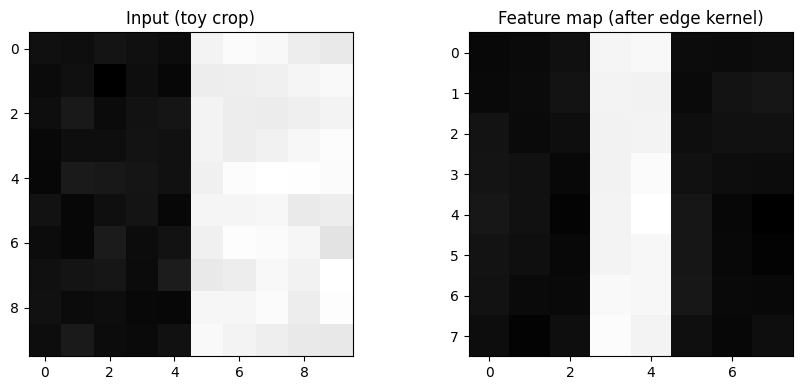

The bright column in the feature map marks exactly where the dark-to-bright edge sits --
everywhere flat (uniform background or uniform object) produced a near-zero response.


In [3]:
# A vertical-edge detection kernel: strongly positive where dark sits to the left of bright
edge_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

feature_map = manual_convolve2d(toy, edge_kernel)
print("Feature map shape:", feature_map.shape, " (10x10 input, 3x3 kernel, no padding -> 8x8 output)")
print(np.round(feature_map, 2))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(toy, cmap="gray")
axes[0].set_title("Input (toy crop)")
axes[1].imshow(feature_map, cmap="gray")
axes[1].set_title("Feature map (after edge kernel)")
plt.tight_layout()
plt.show()
print("The bright column in the feature map marks exactly where the dark-to-bright edge sits --")
print("everywhere flat (uniform background or uniform object) produced a near-zero response.")

---
## 3. Kernels as Pattern Detectors

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Different kernels detect different patterns. Below are two more classic, hand-designed kernels.
In a real CNN, we never write these numbers by hand -- **the kernel values are learned weights**,
adjusted by backpropagation exactly like every weight in Lesson 16. We use hand-picked kernels here
only so the numbers are interpretable before autograd takes over.
</div>

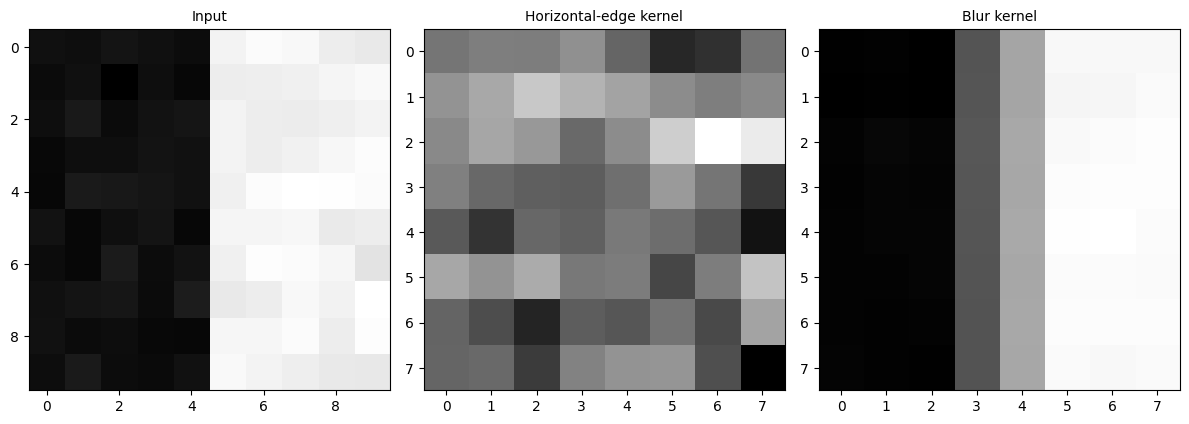

The horizontal kernel responds weakly here -- our toy edge runs vertically, not horizontally.
The blur kernel just smooths everything -- useful for noise reduction, not for finding edges.


In [4]:
horizontal_kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

blur_kernel = np.ones((3, 3)) / 9.0   # simple averaging kernel -- smooths the image

fmap_horizontal = manual_convolve2d(toy, horizontal_kernel)
fmap_blur = manual_convolve2d(toy, blur_kernel)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = ["Input", "Horizontal-edge kernel", "Blur kernel"]
images = [toy, fmap_horizontal, fmap_blur]
for ax, title, im in zip(axes, titles, images):
    ax.imshow(im, cmap="gray")
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.show()
print("The horizontal kernel responds weakly here -- our toy edge runs vertically, not horizontally.")
print("The blur kernel just smooths everything -- useful for noise reduction, not for finding edges.")

---
## 4. Pooling: Keeping What Matters

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

After convolution, **pooling** shrinks the feature map by summarizing small windows -- usually with
**max pooling**: take the largest value in each 2x2 block, discard the rest. This does two things:

1. Reduces the number of values flowing to the next layer (fewer parameters downstream).
2. Keeps the *strongest* signal in each region -- a small shift in exactly where an edge falls
   barely changes the pooled output, which makes the network more tolerant of position.
</div>

In [5]:
def manual_max_pool2d(fmap, size=2):
    h, w = fmap.shape
    oh, ow = h // size, w // size
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            block = fmap[i*size:(i+1)*size, j*size:(j+1)*size]
            out[i, j] = block.max()
    return out

pooled = manual_max_pool2d(feature_map, size=2)
print(f"Feature map shape before pooling: {feature_map.shape}")
print(f"Feature map shape after 2x2 max pooling: {pooled.shape}")
print()
print(np.round(pooled, 2))

Feature map shape before pooling: (8, 8)
Feature map shape after 2x2 max pooling: (4, 4)

[[-0.02  2.98  3.03  0.12]
 [ 0.09  2.95  3.06  0.06]
 [ 0.13  2.98  3.12 -0.06]
 [ 0.08  3.08  3.02  0.02]]


---
## 5. Building Blocks in PyTorch: Conv2d, MaxPool2d, Flatten

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Everything above -- sliding a kernel, summing products, max-pooling -- is exactly what these three
PyTorch layers do, fully vectorized and with **learnable** kernel weights:

| Layer | What it does | Key arguments |
|---|---|---|
| `nn.Conv2d(in_channels, out_channels, kernel_size, padding)` | Slides `out_channels` learned kernels over the input | `padding=1` with `kernel_size=3` keeps the image the same height/width |
| `nn.MaxPool2d(kernel_size)` | Max-pools each window | `kernel_size=2` halves height and width |
| `nn.Flatten()` | Collapses the final `(channels, height, width)` feature map into one long vector, ready for `nn.Linear` | -- |

`in_channels=1` because our images are single-channel grayscale, the same way an RGB photo would use
`in_channels=3`.
</div>

In [6]:
# Confirm shapes: PyTorch expects images as (batch, channels, height, width)
toy_t = torch.tensor(toy, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1, 1, 10, 10)
print("Input tensor shape:", toy_t.shape)

conv_demo = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, padding=1)
pool_demo = nn.MaxPool2d(kernel_size=2)

with torch.no_grad():
    out_conv = conv_demo(toy_t)
    out_pool = pool_demo(out_conv)

print("After Conv2d(1 -> 4 channels, padding=1):", out_conv.shape, " (padding kept 10x10 spatial size)")
print("After MaxPool2d(2):                       ", out_pool.shape, " (halved to 5x5)")
print()
print("4 output channels means 4 independent learned kernels ran over the same input --")
print("each one free to specialize in detecting a different pattern during training.")

Input tensor shape: torch.Size([1, 1, 10, 10])
After Conv2d(1 -> 4 channels, padding=1): torch.Size([1, 4, 10, 10])  (padding kept 10x10 spatial size)
After MaxPool2d(2):                        torch.Size([1, 4, 5, 5])  (halved to 5x5)

4 output channels means 4 independent learned kernels ran over the same input --
each one free to specialize in detecting a different pattern during training.


---
## 6. A Real Public Dataset: Fashion-MNIST

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

**Fashion-MNIST** (Xiao, Rasul & Vollgraf, Zalando Research, 2017) is 70,000 grayscale 28x28 images
of clothing across 10 categories -- a drop-in replacement for the original handwritten-digit MNIST
dataset. It is one of the most widely used "hello world" datasets for image classification because:

- It's small (about 30 MB) and loads in seconds, even on a laptop.
- It's genuinely harder than digit MNIST (a plain classifier scores ~99% on digits but only ~90% on
  clothing), so accuracy numbers actually mean something.
- It's free, public, and requires no registration or API key.

To keep this lesson's story parallel to the Petroleum Engineering track (a **binary** fault /
no-fault classifier), we pull out two of the ten classes: **Sneaker** and **Ankle boot**. Both are
footwear -- similar overall shape, different at the ankle -- which makes this a genuine, non-trivial
visual discrimination task, not a coin flip.

The cell below downloads the four official Fashion-MNIST files (images + labels, train + test) the
first time it runs, and reuses the local copies on every run after that.
</div>

In [7]:
import os, gzip, struct, urllib.request

DATA_DIR = "../data/fashion_mnist"
BASE_URL = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
FILES = [
    "train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz", "t10k-labels-idx1-ubyte.gz",
]

os.makedirs(DATA_DIR, exist_ok=True)
for fn in FILES:
    path = os.path.join(DATA_DIR, fn)
    if not os.path.exists(path):
        print(f"Downloading {fn} ...")
        urllib.request.urlretrieve(BASE_URL + fn, path)
    else:
        print(f"Found cached {fn}")

def read_idx_images(path):
    with gzip.open(path, "rb") as f:
        _, n, rows, cols = struct.unpack(">IIII", f.read(16))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows, cols)

def read_idx_labels(path):
    with gzip.open(path, "rb") as f:
        _, n = struct.unpack(">II", f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)

X_train_full = read_idx_images(os.path.join(DATA_DIR, "train-images-idx3-ubyte.gz"))
y_train_full = read_idx_labels(os.path.join(DATA_DIR, "train-labels-idx1-ubyte.gz"))
X_test_full = read_idx_images(os.path.join(DATA_DIR, "t10k-images-idx3-ubyte.gz"))
y_test_full = read_idx_labels(os.path.join(DATA_DIR, "t10k-labels-idx1-ubyte.gz"))

print(f"\nFull training set: {X_train_full.shape}, full test set: {X_test_full.shape}")
print("Class labels (Fashion-MNIST standard): 0 T-shirt/top 1 Trouser 2 Pullover 3 Dress 4 Coat")
print("                                       5 Sandal 6 Shirt 7 Sneaker 8 Bag 9 Ankle boot")

Found cached train-images-idx3-ubyte.gz
Found cached train-labels-idx1-ubyte.gz
Found cached t10k-images-idx3-ubyte.gz
Found cached t10k-labels-idx1-ubyte.gz



Full training set: (60000, 28, 28), full test set: (10000, 28, 28)
Class labels (Fashion-MNIST standard): 0 T-shirt/top 1 Trouser 2 Pullover 3 Dress 4 Coat
                                       5 Sandal 6 Shirt 7 Sneaker 8 Bag 9 Ankle boot


Training set: (1000, 28, 28), class balance: [500 500]
Test set:     (300, 28, 28), class balance: [150 150]


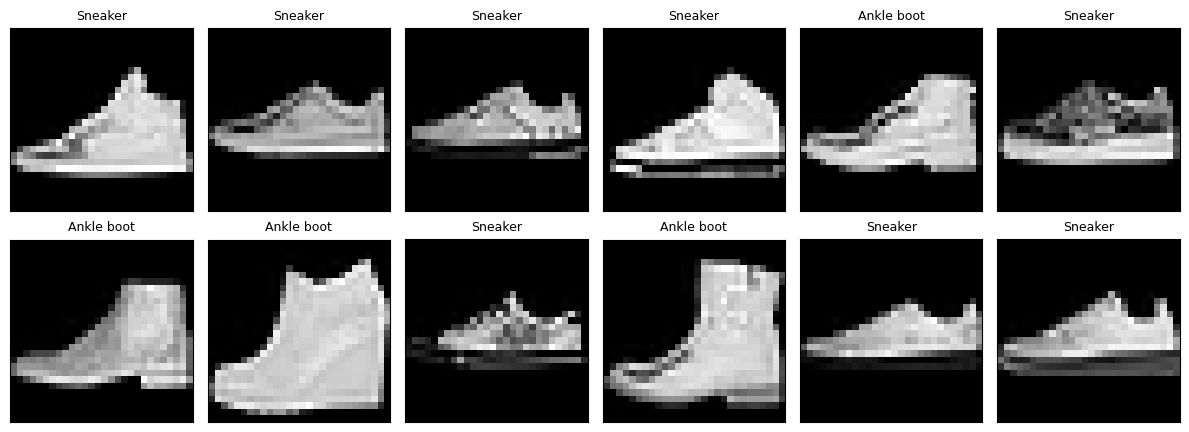

In [8]:
CLASS_A, CLASS_B = 7, 9   # Sneaker vs Ankle boot
NAME_A, NAME_B = "Sneaker", "Ankle boot"
N_PER_CLASS_TRAIN = 500
N_PER_CLASS_TEST = 150

def subset_two_classes(X_full, y_full, n_per_class, rng):
    idx_a = rng.choice(np.where(y_full == CLASS_A)[0], size=n_per_class, replace=False)
    idx_b = rng.choice(np.where(y_full == CLASS_B)[0], size=n_per_class, replace=False)
    idx = np.concatenate([idx_a, idx_b])
    rng.shuffle(idx)
    X = X_full[idx].astype(np.float32) / 255.0    # scale pixel values to [0, 1]
    y = (y_full[idx] == CLASS_B).astype(np.float32)  # 0 = Sneaker, 1 = Ankle boot
    return X, y

rng = np.random.default_rng(42)
X_train, y_train = subset_two_classes(X_train_full, y_train_full, N_PER_CLASS_TRAIN, rng)
X_test, y_test = subset_two_classes(X_test_full, y_test_full, N_PER_CLASS_TEST, rng)

print(f"Training set: {X_train.shape}, class balance: {np.bincount(y_train.astype(int))}")
print(f"Test set:     {X_test.shape}, class balance: {np.bincount(y_test.astype(int))}")

fig, axes = plt.subplots(2, 6, figsize=(12, 4.5))
show_idx = rng.choice(len(X_train), size=12, replace=False)
for ax, idx in zip(axes.flat, show_idx):
    ax.imshow(X_train[idx], cmap="gray")
    ax.set_title(NAME_B if y_train[idx] == 1 else NAME_A, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

In [9]:
# PyTorch images need a channel dimension: (N, 1, H, W)
X_train_t = torch.tensor(X_train).unsqueeze(1)
X_test_t = torch.tensor(X_test).unsqueeze(1)
y_train_t = torch.tensor(y_train).view(-1, 1)
y_test_t = torch.tensor(y_test).view(-1, 1)

print("Training tensor shape:", X_train_t.shape)
print("Test tensor shape:    ", X_test_t.shape)

Training tensor shape: torch.Size([1000, 1, 28, 28])
Test tensor shape:     torch.Size([300, 1, 28, 28])


---
## 7. Your First CNN with nn.Sequential

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Two convolution blocks (`Conv2d -> ReLU -> MaxPool2d`), then flatten and finish with the same kind
of dense layers from Lesson 16. `padding=1` with a 3x3 kernel keeps spatial size unchanged inside
each block, so pooling alone controls the shrinkage: 28 -> 14 -> 7.
</div>

In [10]:
model = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),   # 1 -> 8 channels, 28x28 -> 28x28
    nn.ReLU(),
    nn.MaxPool2d(2),                             # 28x28 -> 14x14

    nn.Conv2d(8, 16, kernel_size=3, padding=1),  # 8 -> 16 channels, 14x14 -> 14x14
    nn.ReLU(),
    nn.MaxPool2d(2),                             # 14x14 -> 7x7

    nn.Flatten(),                                # 16 x 7 x 7 = 784 values
    nn.Linear(16 * 7 * 7, 32),
    nn.ReLU(),
    nn.Linear(32, 1)                             # one logit: Ankle boot (1) vs Sneaker (0)
)

print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")
print("Compare this to a flatten-then-dense network on the same 784 pixels (Section 1) --")
print("weight *sharing* inside each Conv2d kernel is what keeps this number manageable.")

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=784, out_features=32, bias=True)
  (8): ReLU()
  (9): Linear(in_features=32, out_features=1, bias=True)
)

Total trainable parameters: 26,401
Compare this to a flatten-then-dense network on the same 784 pixels (Section 1) --
weight *sharing* inside each Conv2d kernel is what keeps this number manageable.


---
## 8. Loss and Optimizer for Image Classification

<div style="background: #fff8e1; border-left: 5px solid #e0a800; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Lesson 16 used `nn.MSELoss()` for a regression target (a continuous number). Today's target is
binary (Sneaker / Ankle boot), so we use `nn.BCEWithLogitsLoss()` -- Binary Cross-Entropy. It expects
the model's raw output (a "logit"), and internally applies a sigmoid to squash it into a 0-1
probability before comparing to the true 0/1 label. Using this combined loss instead of a separate
sigmoid + `nn.BCELoss()` is more numerically stable -- the standard PyTorch recommendation.
</div>

In [11]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

with torch.no_grad():
    logits_untrained = model(X_train_t)
    initial_loss = loss_fn(logits_untrained, y_train_t)
print(f"BCE loss before any training: {initial_loss.item():.4f}")
print("(random guessing on a balanced binary problem gives BCE loss near ln(2) = 0.693)")

BCE loss before any training: 0.6960
(random guessing on a balanced binary problem gives BCE loss near ln(2) = 0.693)


---
## 9. The Training Loop

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

Same four steps as Lesson 16, Section 8: forward pass, compute loss, backward pass, optimizer step.
We additionally track training **accuracy** each epoch by turning logits into 0/1 predictions with
`(logits > 0)`, which is equivalent to checking whether the sigmoid probability exceeds 0.5.
</div>

In [12]:
n_epochs = 30
train_losses, train_accs = [], []

for epoch in range(n_epochs):
    model.train()

    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        preds = (logits > 0).float()
        acc = (preds == y_train_t).float().mean().item()

    train_losses.append(loss.item())
    train_accs.append(acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs}  |  loss = {loss.item():.4f}  |  train acc = {acc:.3f}")

Epoch   5/30  |  loss = 0.6810  |  train acc = 0.829


Epoch  10/30  |  loss = 0.6539  |  train acc = 0.916


Epoch  15/30  |  loss = 0.6091  |  train acc = 0.913


Epoch  20/30  |  loss = 0.5412  |  train acc = 0.914


Epoch  25/30  |  loss = 0.4503  |  train acc = 0.913


Epoch  30/30  |  loss = 0.3508  |  train acc = 0.909


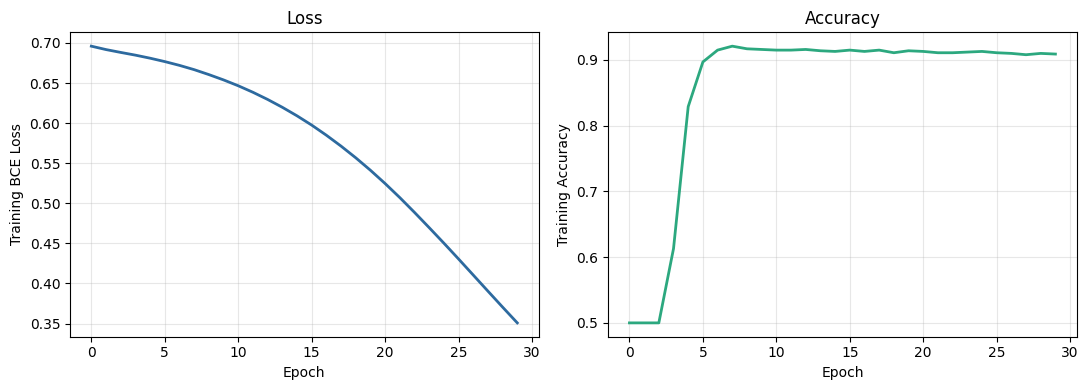

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(train_losses, color="#2d6a9f", linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Training BCE Loss"); axes[0].grid(alpha=0.3)
axes[0].set_title("Loss")

axes[1].plot(train_accs, color="#2ca87f", linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Training Accuracy"); axes[1].grid(alpha=0.3)
axes[1].set_title("Accuracy")
plt.tight_layout()
plt.show()

---
## 10. Evaluate: Accuracy on Held-Out Images

<div style="background: #f0f7ff; border-left: 5px solid #2d6a9f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

`model.eval()` and `torch.no_grad()` -- same practice as Lesson 16, Section 9 -- before checking
performance on images the network never trained on.
</div>

In [14]:
from sklearn.metrics import accuracy_score

model.eval()
with torch.no_grad():
    logits_test = model(X_test_t)
    preds_test = (logits_test > 0).float()

test_acc = accuracy_score(y_test_t.numpy(), preds_test.numpy())
print(f"Test accuracy: {test_acc:.3f}")

Test accuracy: 0.927


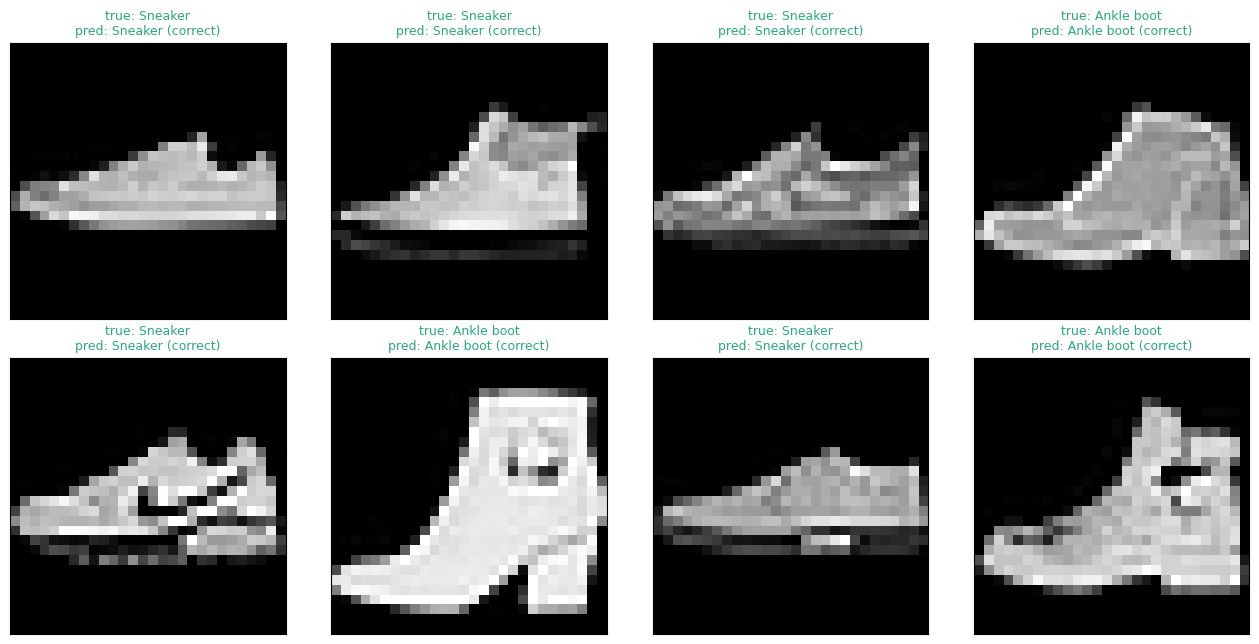

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
rng_show = np.random.default_rng(7)
sample_idx = rng_show.choice(len(X_test), size=8, replace=False)

for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(X_test[idx], cmap="gray")
    true_label = NAME_B if y_test[idx] == 1 else NAME_A
    pred_label = NAME_B if preds_test[idx].item() == 1 else NAME_A
    correct = "correct" if pred_label == true_label else "WRONG"
    color = "#2ca87f" if correct == "correct" else "#c0392b"
    ax.set_title(f"true: {true_label}\npred: {pred_label} ({correct})", fontsize=9, color=color)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

---
## 11. Student Activity

<div style="background: #fff3cd; border-left: 5px solid #ffc107; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### Activity: Look Inside the Trained Kernels

`model[0]` is the first `Conv2d` layer. Its learned kernels live in `model[0].weight`, shape
`(8, 1, 3, 3)` -- 8 kernels, each `1x3x3`. Plot all 8 as small grayscale images (use
`.detach().numpy()` to pull the tensor out of the graph first).

Do any of them resemble the hand-picked edge or blur kernels from Sections 2-3? Write one sentence
in a new markdown cell describing what you see.
</div>

In [16]:
# Activity -- plot the 8 learned first-layer kernels as a 2x4 grid of small images
# Hint: kernels = model[0].weight.detach().numpy()   # shape (8, 1, 3, 3)
#       kernels[i, 0] is the i-th 3x3 kernel





---
## 12. Recap & Homework

<div style="background: #e8f5e9; border-left: 5px solid #2ca87f; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 12px 0;">

### What You Learned

| Concept | Meaning |
|---------|---------|
| Convolution | Slide a small kernel over an image, multiply and sum, one output pixel per position |
| Kernel / filter | A small learned weight matrix; different kernels detect different patterns |
| Feature map | The output image produced by convolving one kernel across the input |
| Pooling | Downsample a feature map (e.g. max over 2x2 blocks), keeping the strongest signal |
| `nn.Conv2d` / `nn.MaxPool2d` / `nn.Flatten` | PyTorch's vectorized, learnable versions of the manual functions above |
| `nn.BCEWithLogitsLoss` | Binary cross-entropy loss for two-class problems, numerically stable with raw logits |
| Fashion-MNIST | A real, public, 70,000-image benchmark dataset -- today's source of ground truth |

</div>

### Homework

**Task 1 -- Go Deeper**

Add a third convolution block (`nn.Conv2d(16, 32, kernel_size=3, padding=1)`, `nn.ReLU()`,
`nn.MaxPool2d(2)`) before the `Flatten`, and update the first `nn.Linear` input size accordingly
(spatial size shrinks one more time: 7x7 does not halve evenly, so switch the second pool to
`nn.MaxPool2d(2, ceil_mode=True)` and recompute the flattened size by printing the shape after
`nn.Flatten()` before hard-coding it). Retrain from scratch and compare test accuracy to the
two-block baseline.

**Task 2 -- Bigger Kernels**

Rebuild the model with `kernel_size=5` (keep `padding=2` so spatial size is still preserved) in both
convolution blocks. Retrain and compare test accuracy and training time to the 3x3 baseline.

**Task 3 (Engineering) -- A Harder Pair**

Change `CLASS_A, CLASS_B` in Section 6 to `6, 0` (**Shirt** vs **T-shirt/top**) -- two classes that
are famously difficult to separate in Fashion-MNIST. Regenerate the dataset, retrain the Section 7
model, and report the new test accuracy. Why do you think this pair is so much harder than Sneaker
vs Ankle boot?

In [17]:
# Homework Task 1 -- Go Deeper
# Hint: rebuild model as a 3-conv-block nn.Sequential, fresh optimizer, reuse the Section 9 training loop.





In [18]:
# Homework Task 2 -- Bigger Kernels
# Hint: kernel_size=5, padding=2 in both Conv2d layers; spatial size logic is unchanged (still 28->14->7).





In [19]:
# Homework Task 3 (Engineering) -- A Harder Pair
# Hint: CLASS_A, CLASS_B = 6, 0  (Shirt vs T-shirt/top), then rerun Section 6's subset_two_classes calls.





<div style="background: #1a3a5c; color: white; padding: 22px 26px; border-radius: 10px; margin-top: 18px;">
  <h3 style="margin-top: 0; color: #ffffff;">Lesson Complete</h3>
  <p style="margin-bottom: 0; color: #d8ecff;">
    You built a convolution and a max-pool by hand, then trained a real CNN to tell sneakers from
    ankle boots in a genuine public benchmark dataset. Next, Lesson 18 goes deeper: a three-block
    CNN, dropout to fight overfitting, and evaluation metrics that matter more than accuracy when a
    false negative is costlier than a false alarm -- plus a look inside the network at what each
    layer actually "sees."
  </p>
</div>